In [1]:
import importlib
import stochastic_interpolants
importlib.reload(stochastic_interpolants)
from stochastic_interpolants import *

from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/njung3/miniconda3/envs/flow311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Create MLP Model with sin/cos time embedding. Consult https://www.kaggle.com/code/lorentzyeung/positional-embeddings-clearly-explained for more information on this type of time embedding.

In [2]:
# image size
IMG_SIZE = 28
# input size
IN_S = IMG_SIZE ** 2
# hidden size
H_S = 1024
# amount of layers
L = 8
# output size
OUT_S = IN_S
# time dimensions
T_D = 128

model = MLP(input_size = IN_S, hidden_size = H_S, amount_layers = L, output_size = OUT_S, time_dimension = T_D)
model = model.to(device)

## Define Distributions

In [3]:
dataset_target = load_dataset("natejuw/mnist-28x28")
dataset_base = dataset_target.copy()
dataset_base["train"] = dataset_to_gaussian(dataset_base)

dataset_target = prime_dataset(dataset_target)
dataset_base = prime_dataset(dataset_base)

## Define Interpolant

In [6]:
interpolant = Interpolant('variance_preserve')

## Now we want to train the model.

step 200/10000 | obj -0.602550 | mse 1.174529 | grad_norm 0.1207 | pred_mean -0.7701 | I_mean -0.7675 | pred_std 0.8891
step 400/10000 | obj -0.565768 | mse 1.240681 | grad_norm 0.1567 | pred_mean -0.7273 | I_mean -0.6874 | pred_std 0.8280
step 600/10000 | obj -0.572671 | mse 1.231572 | grad_norm 0.1168 | pred_mean -0.7115 | I_mean -0.7022 | pred_std 0.8389
step 800/10000 | obj -0.629854 | mse 1.126513 | grad_norm 0.1204 | pred_mean -0.7632 | I_mean -0.7611 | pred_std 0.8625
step 1000/10000 | obj -0.586518 | mse 1.222683 | grad_norm 0.1272 | pred_mean -0.7262 | I_mean -0.7074 | pred_std 0.8151
step 1200/10000 | obj -0.593048 | mse 1.183838 | grad_norm 0.1248 | pred_mean -0.7456 | I_mean -0.7308 | pred_std 0.8458
step 1400/10000 | obj -0.607066 | mse 1.143560 | grad_norm 0.114 | pred_mean -0.7638 | I_mean -0.7702 | pred_std 0.8745
step 1600/10000 | obj -0.582994 | mse 1.195376 | grad_norm 0.1163 | pred_mean -0.744 | I_mean -0.7531 | pred_std 0.8826
step 1800/10000 | obj -0.594152 | mse 

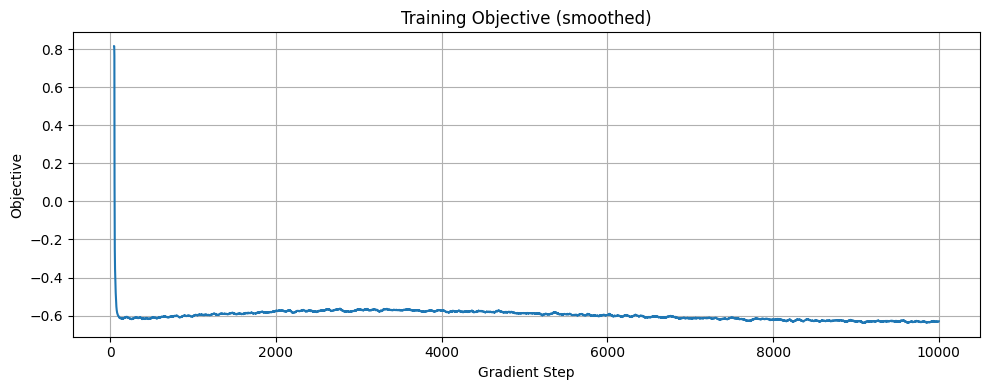

In [9]:
model = model.to(device)

train_type = 'velocity'
gradient_steps = 10000
batch_size = 200
log_every = 200
base_learning_rate = 5e-3
weight_decay = 1e-7
out_name = "noise_to_mnist_example.pt"

interpolant.train_model(model = model, dataset_base = dataset_base, dataset_target = dataset_target, 
train_type = train_type, n_iterations = gradient_steps,
batch_size = batch_size, log_every = log_every, base_lr = 5e-3, weight_decay = 1e-7,
out_name = out_name, make_plot = True)

## Now we view the flow
when we run the noise to mnist for 15,000 gradient steps we get the following, we can see that there is something there. this is with alpha(t)=cos(pi/2 t) and beta(t) = sin(pi/2 t) with gamma(t)=0.

starting from dataset item 465


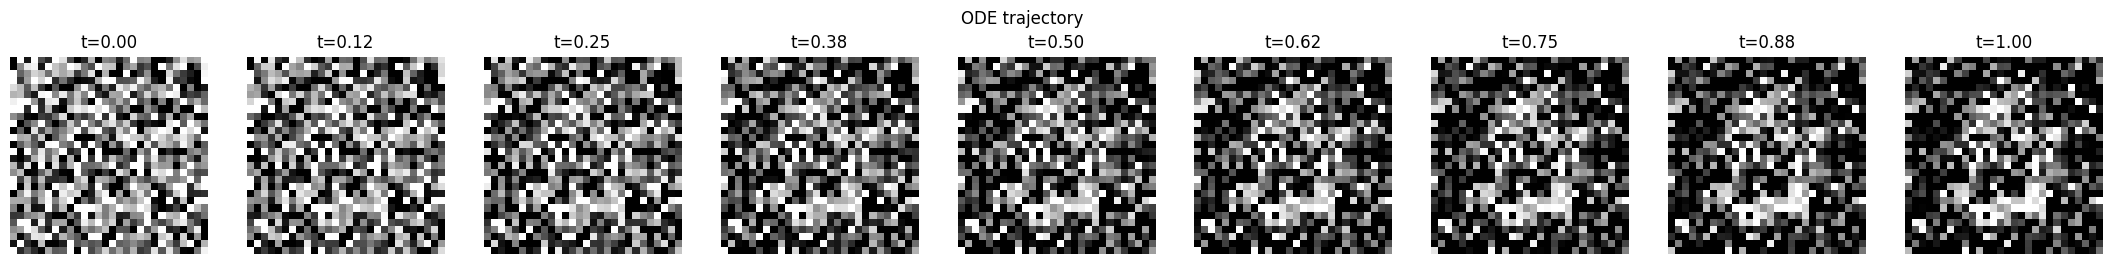

In [28]:
run_flow(dataset_base, model, n_steps = 2000, save_frames = 9, img_size = 28, use_random=True)

## Nonzero Gamma

In [29]:
# image size
IMG_SIZE = 28
# input size
IN_S = IMG_SIZE ** 2
# hidden size
H_S = 1024
# amount of layers
L = 8
# output size
OUT_S = IN_S
# time dimensions
T_D = 128

model_new = MLP(input_size = IN_S, hidden_size = H_S, amount_layers = L, output_size = OUT_S, time_dimension = T_D)
model_new = model_new.to(device)

In [30]:
interpolant_new = Interpolant('trig_noise')

In [31]:
model_new = model_new.to(device)

train_type = 'velocity'
gradient_steps = 20000
batch_size = 200
log_every = 200
base_learning_rate = 1e-4
weight_decay = 1e-7
out_name = "noise_to_mnist_gamma.pt"

model_new = fetch_model('noise_to_mnist_gamma.pt', IN_S, H_S, L, T_D)

interpolant_new.train_model(model = model_new, dataset_base = dataset_base, dataset_target = dataset_target, 
train_type = train_type, n_iterations = gradient_steps,
batch_size = batch_size, log_every = log_every, base_lr = 1e-4, weight_decay = 1e-7,
out_name = out_name, rand_run = True)

Model loaded successfully from noise_to_mnist_gamma.pt
step 200/20000 | obj -0.844343 | mse 1.048613 | grad_norm 0.7486 | pred_mean -0.7104 | I_mean -0.7133 | pred_std 1.0372


KeyboardInterrupt: 

Model loaded successfully from noise_to_mnist_gamma.pt
starting from dataset item 100


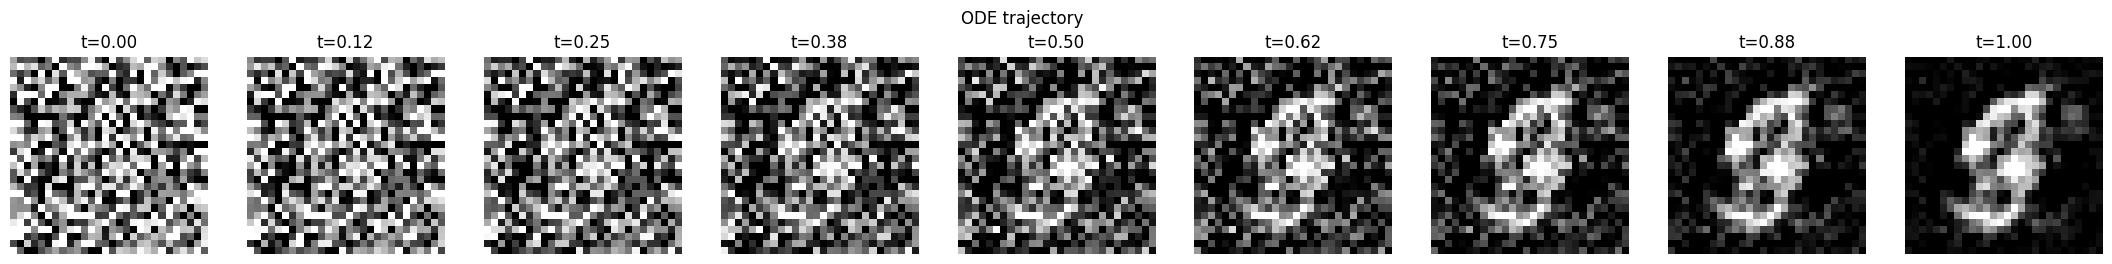

In [37]:
model_new = fetch_model('noise_to_mnist_gamma.pt', IN_S, H_S, L, T_D)
run_flow(dataset_base, model_new, n_steps = 5000, save_frames = 9, img_size = 28, use_random=True)

## FID Evaluation

In [8]:
# we consider the first model which we used a gamma which was identically zero
model_zero_gamma = fetch_model('noise_to_mnist.pt', IN_S, H_S, L, T_D)
fid_zero_gamma = fid_from_gaussian(model_zero_gamma, dataset_target, steps = 1000, batch_size = 1024)

Model loaded successfully from noise_to_mnist.pt


/home/njung3/code/flow_matching/stochastic_interpolants.py:385: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma_real @ sigma_fake)


In [10]:
print(fid_zero_gamma)

68.26859259202949


In [38]:
model_with_gamma = fetch_model('noise_to_mnist_gamma.pt', IN_S, H_S, L, T_D)
fid_with_gamma = fid_from_gaussian(model_with_gamma, dataset_target, steps = 1000, batch_size = 1024)

Model loaded successfully from noise_to_mnist_gamma.pt


Flowing batches: 100%|██████████| 10/10 [01:08<00:00,  6.84s/it]


Done. Removed 1570 samples total due to blowup


Filtering samples: 100%|██████████| 8430/8430 [00:00<00:00, 103314.02it/s]


Removed 498 samples outside [-2, 2] threshold=0.9. Kept 7932/8430


In [39]:
print(fid_with_gamma)

9.646777736902168
